In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the cancer prediction dataset
raw = pd.read_csv("Cancer_Prediction.csv")

# Drop the id column, the diagnosis label and any all-empty trailing column.
# K-Means is unsupervised, so 'diagnosis' is kept aside only for later comparison.
labels = raw["diagnosis"]
df = raw.drop(columns=["id", "diagnosis"], errors="ignore")
df = df.dropna(axis=1, how="all")

features = df.columns.tolist()
data = df.values

# Standardize the data (important here: the features have very different scales)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

print("Shape:", df.shape)
print("Features:", features)


Shape: (569, 30)
Features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [2]:
df.head()


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


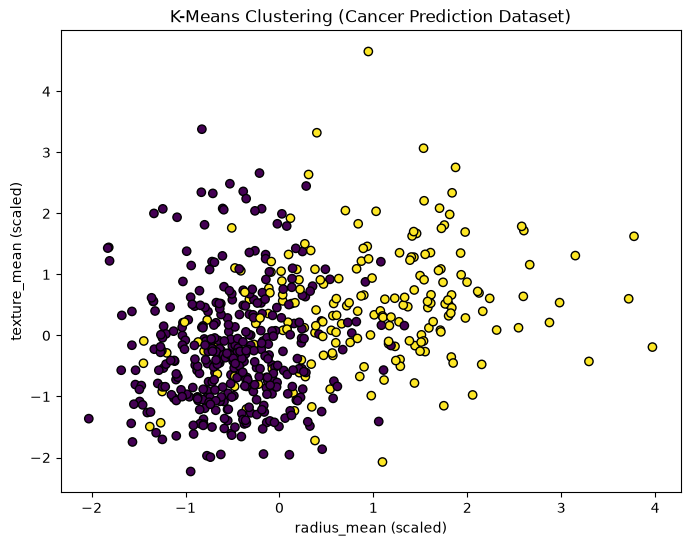

Centroids of clusters:
[[-0.48299485 -0.23904142 -0.50041892 -0.47814154 -0.3110035  -0.52601873
  -0.57903569 -0.58717117 -0.30908386 -0.1491409  -0.42798514 -0.02110994
  -0.43097168 -0.40175149 -0.02383127 -0.37020054 -0.3345976  -0.39771232
  -0.07493017 -0.23682231 -0.51785387 -0.25147802 -0.53231144 -0.49935772
  -0.31607814 -0.49224121 -0.53684332 -0.58010099 -0.30335497 -0.33672889]
 [ 0.93362406  0.4620646   0.96730462  0.92424266  0.60116657  1.01678879
   1.11927003  1.13499581  0.59745592  0.28828783  0.82729086  0.0408053
   0.83306382  0.77658149  0.0460656   0.71559384  0.64677371  0.76877382
   0.14483925  0.45777508  1.00100618  0.48610441  1.02895252  0.96525332
   0.61097579  0.95149718  1.0377126   1.12132923  0.58638203  0.65089347]]

Inertia: 11595.526607115788

Data with cluster assignments:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57        

In [3]:
# K-Means clustering (2 clusters: the data has two diagnosis groups, M and B)
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans.fit(df_scaled)

# Add the predicted clusters to the DataFrame
df["Cluster"] = kmeans.labels_

# Visualize the clusters with a scatter plot (using only two dimensions for visualization)
x_idx = features.index("radius_mean")
y_idx = features.index("texture_mean")

plt.figure(figsize=(8, 6))
plt.scatter(df_scaled[:, x_idx], df_scaled[:, y_idx], c=kmeans.labels_,
            cmap="viridis", marker="o", edgecolor="k")
plt.title("K-Means Clustering (Cancer Prediction Dataset)")
plt.xlabel(features[x_idx] + " (scaled)")
plt.ylabel(features[y_idx] + " (scaled)")
plt.show()

# Print centroids and inertia
print("Centroids of clusters:")
print(kmeans.cluster_centers_)
print("\nInertia:", kmeans.inertia_)

# Show first few rows of data with cluster assignment
print("\nData with cluster assignments:")
print(df.head())


In [4]:
# Compare the unsupervised clusters against the actual diagnosis labels
comparison = pd.crosstab(df["Cluster"], labels, rownames=["Cluster"], colnames=["Diagnosis"])
print(comparison)

# Accuracy if each cluster is mapped to its majority diagnosis
accuracy = comparison.max(axis=1).sum() / comparison.values.sum()
print("\nAgreement with diagnosis labels: {:.2%}".format(accuracy))


Diagnosis    B    M
Cluster            
0          339   36
1           18  176

Agreement with diagnosis labels: 90.51%


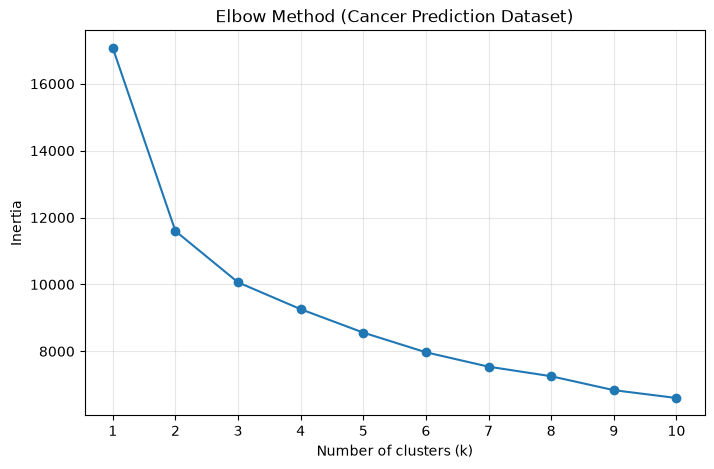

In [5]:
# Elbow method: inertia for different values of k
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(df_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.title("Elbow Method (Cancer Prediction Dataset)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()


In [6]:
df


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Cluster
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1
